# California Housing Dataset

In [1]:
from Code.california_housing_dataset_cleaning import clean_data
from sklearn.datasets import fetch_california_housing


print(f"Processing dataset: California Housing")
data = fetch_california_housing(as_frame=True)
features_of_interest = ["AveRooms", "AveBedrms", "AveOccup", "Population"]
data.frame[features_of_interest].describe()

data = fetch_california_housing(as_frame=True)
print("Size of initial data : " + str(len(data.frame)))
features_of_interest = ["AveRooms", "AveBedrms", "AveOccup", "Population"]
data = clean_data(data, features_of_interest)
print("Size of data after cleaning : " + str(len(data.frame)))

X_cal, y_cal, feat_names = data.frame.drop('MedHouseVal', axis=1), data.frame['MedHouseVal'], data.feature_names
X_cal = X_cal.values
y_cal = y_cal.values

n_samples, n_features = X_cal.shape
print("n_samples : " + str(n_samples))

Processing dataset: California Housing
Size of initial data : 20640
Number of illogical examples:  5
Illogical examples : [3364, 13034, 16669, 19006, 15360]
Per feature the illogical examples are :
HouseAge:  0
AveRooms:  0
AveBeds:  0
Population:  1
AveOccup:  4
Dropping those examples from data
Size of data after cleaning : 20635
n_samples : 20635


In [57]:
type(X_cal)

numpy.ndarray

In [58]:
type(y_cal)

numpy.ndarray

In [48]:
print(feat_names)

print("____________")

print(X_cal[3363])

print("____________")
print(X_cal[3364])

print("____________")

print(X_cal[3365])

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
____________
[   1.7333       19.            5.42519685    1.12598425  355.
    2.79527559   40.45       -120.36      ]
____________
[ 5.51790000e+00  3.60000000e+01  5.14285714e+00  1.14285714e+00
  4.19800000e+03  5.99714286e+02  4.04100000e+01 -1.20510000e+02]
____________
[ 3.40280000e+00  1.70000000e+01  5.93870403e+00  1.09106830e+00
  1.52900000e+03  2.67775832e+00  4.02900000e+01 -1.20540000e+02]


# KNN regressor

In [59]:
from src.lazy import KNNRegressor
from src.trees import HoeffdingTreeRegressor
from sklearn.metrics import mean_squared_error

knn = KNNRegressor()
ht = HoeffdingTreeRegressor()
actual_labels = []
knn_predictions = []
ht_predictions = []
knn_mse_list = []
ht_mse_list = []
for i in range(len(X_cal)):


    instance_features = X_cal[i].reshape(1, -1)
    actual_value = y_cal[i]
    actual_labels.append(actual_value)

    # Predict
    knn_pred = knn.predict(instance_features)[0]
    knn_predictions.append(knn_pred)

    knn_temp_mse = mean_squared_error(actual_labels, knn_predictions)
    knn_mse_list.append(knn_temp_mse)

    ht_pred = ht.predict(instance_features)[0]
    ht_predictions.append(ht_pred)

    ht_temp_mse = mean_squared_error(actual_labels, ht_predictions)
    ht_mse_list.append(ht_temp_mse)

    # Fit
    knn.partial_fit(X=instance_features, y=[actual_value])
    ht.partial_fit(X=instance_features, y=[actual_value])

knn_mse = mean_squared_error(actual_labels, knn_predictions)
ht_mse = mean_squared_error(actual_labels, ht_predictions)


/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operati

In [60]:
print(knn_mse)
print(ht_mse)

1.2854617027460344
0.5302946098171396


In [4]:
(knn.data_window.window_size)

1000

# Find the max decimal digits across all elements from a list

In [61]:
def count_decimals(x):
    s = str(x)
    if '.' in s:
        return len(s.split('.')[-1].rstrip('0'))  # Remove trailing zeros
    else:
        return 0


In [62]:
max_decimal_digits_y_true = max(count_decimals(x) for x in y_cal)
print("Maximum number of decimal digits from y_cal :", max_decimal_digits_y_true)

Maximum number of decimal digits from y_cal : 5


In [63]:
max_decimal_digits_knn = max(count_decimals(x) for x in knn_predictions)
print("Maximum number of decimal digits from knn_predictions :", max_decimal_digits_knn)

Maximum number of decimal digits from knn_predictions : 17


In [17]:
max_decimal_digits_ht = max(count_decimals(x) for x in ht_predictions)
print("Maximum number of decimal digits from ht_predictions :", max_decimal_digits_ht)

Maximum number of decimal digits from ht_predictions : 18


# Write prediction lists to txt file

In [64]:
import numpy as np

np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/california_housing/knn.txt", knn_predictions, fmt="%." +str(max_decimal_digits_knn)+"f")

np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/california_housing/ht.txt", ht_predictions, fmt="%." +str(max_decimal_digits_ht)+"f")

In [65]:
np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/california_housing/y_true.txt", y_cal, fmt="%." +str(max_decimal_digits_y_true)+"f")

# TODO : read txt files and produce learning curves

#Plot MSE

# We observe that X_cal[3364] is difficult for Hoeffding Tree!!!!!

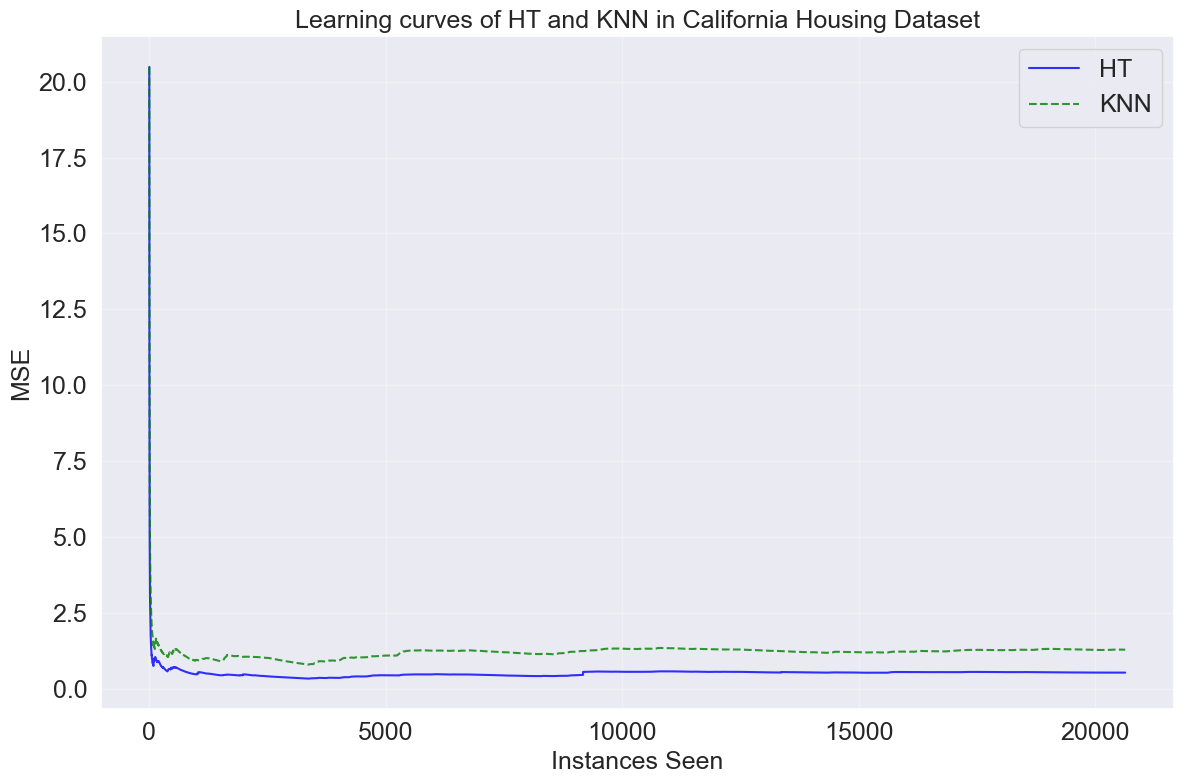

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns



sns.set_theme()

plt.figure(figsize=(12, 8))



# Plot without jitter
#sns.lineplot()
plt.plot(ht_mse_list, label='HT', color='blue', linewidth=1.5, linestyle='-', alpha=0.8)
plt.plot(knn_mse_list, label='KNN', color='green', linewidth=1.5, linestyle='--', alpha=0.8)


plt.title(f"Learning curves of HT and KNN in California Housing Dataset", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel("Instances Seen", fontsize=18)
plt.ylabel('MSE', fontsize=18)
plt.grid(alpha=0.3)
plt.legend(fontsize=18)
plt.tight_layout()

# Save the plot
save_path = '/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/figures/california/knn_ht/mse_curves.png'
plt.savefig(save_path)

plt.show()




# Film Thickness in semiconductors

In [20]:
import pandas as pd

film_thick_data = pd.read_csv("/Users/pantia-marinaalchirch/Documents/OU/Research/Streams/data/semiconductors_korean/train.csv", nrows=20000)

In [39]:
import numpy as np

film_thick_sum_of_layers = film_thick_data.copy()
film_thick_sum_of_layers['sum_of_layers'] = film_thick_sum_of_layers[['layer_1', 'layer_2', 'layer_3', 'layer_4']].sum(axis=1)
film_thick_sum_of_layers = film_thick_sum_of_layers.drop(columns={"layer_1", "layer_2", "layer_3", "layer_4"})
y_sum_of_layers = film_thick_sum_of_layers._get_column_array(226)
X_sum_of_layers = film_thick_sum_of_layers.drop(columns={"sum_of_layers"})
X_sum_of_layers = X_sum_of_layers.astype(np.float32)

film_thick_per_layer = film_thick_data.copy()
target_1 = film_thick_per_layer._get_column_array(0)
target_2 = film_thick_per_layer._get_column_array(1)
target_3 = film_thick_per_layer._get_column_array(2)
y_4 = film_thick_per_layer._get_column_array(3)

X_1 = film_thick_per_layer.drop(columns={"layer_1"})
X_2 = film_thick_per_layer.drop(columns={"layer_2"})
X_3 = film_thick_per_layer.drop(columns={"layer_3"})
X_4 = film_thick_per_layer.drop(columns={"layer_4"})

X_1 = X_1.astype(np.float32)
X_2 = X_2.astype(np.float32)
X_3 = X_3.astype(np.float32)
X_4 = X_4.astype(np.float32)

X = film_thick_per_layer.drop(columns={"layer_1", "layer_2", "layer_3", "layer_4"})


# Sum of layers as target

In [23]:
from src.lazy import KNNRegressor
from src.trees import HoeffdingTreeRegressor
from sklearn.metrics import mean_squared_error

knn = KNNRegressor()
ht = HoeffdingTreeRegressor()
actual_labels = []
knn_predictions_film = []
ht_predictions_film = []
knn_mse_list = []
ht_mse_list = []

for i in range(len(X_sum_of_layers)):


    instance_features = X_sum_of_layers.iloc[i:i+1].values
    actual_value = y_sum_of_layers[i]
    actual_labels.append(actual_value)

    # Predict
    knn_pred = knn.predict(instance_features)[0]
    knn_predictions_film.append(knn_pred)

    ht_pred = ht.predict(instance_features)[0]
    ht_predictions_film.append(ht_pred)

    # Fit
    knn.partial_fit(X=instance_features, y=[actual_value])
    ht.partial_fit(X=instance_features, y=[actual_value])

knn_mse = mean_squared_error(actual_labels, knn_predictions_film)
ht_mse = mean_squared_error(actual_labels, ht_predictions_film)


/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operati

In [26]:
print(knn_mse)
print(ht_mse)

49.0208
8118.252629176666


In [30]:
max_decimal_digits_y_true = max(count_decimals(x) for x in y_sum_of_layers)
print("Maximum number of decimal digits from y_cal :", max_decimal_digits_y_true)
max_decimal_digits_knn = max(count_decimals(x) for x in knn_predictions_film)
print("Maximum number of decimal digits from knn_predictions :", max_decimal_digits_knn)
max_decimal_digits_ht = max(count_decimals(x) for x in ht_predictions_film)
print("Maximum number of decimal digits from ht_predictions :", max_decimal_digits_ht)

Maximum number of decimal digits from y_cal : 0
Maximum number of decimal digits from knn_predictions : 0
Maximum number of decimal digits from ht_predictions : 15


In [29]:
np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/sum_of_targets/knn.txt",
           knn_predictions_film, fmt="%." + str(max_decimal_digits_knn) + "f")

np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/sum_of_targets/ht.txt",
           ht_predictions_film, fmt="%." + str(max_decimal_digits_ht) + "f")
np.savetxt(
    "/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/sum_of_targets/y_true.txt",
    y_sum_of_layers, fmt="%." + str(max_decimal_digits_y_true) + "f")

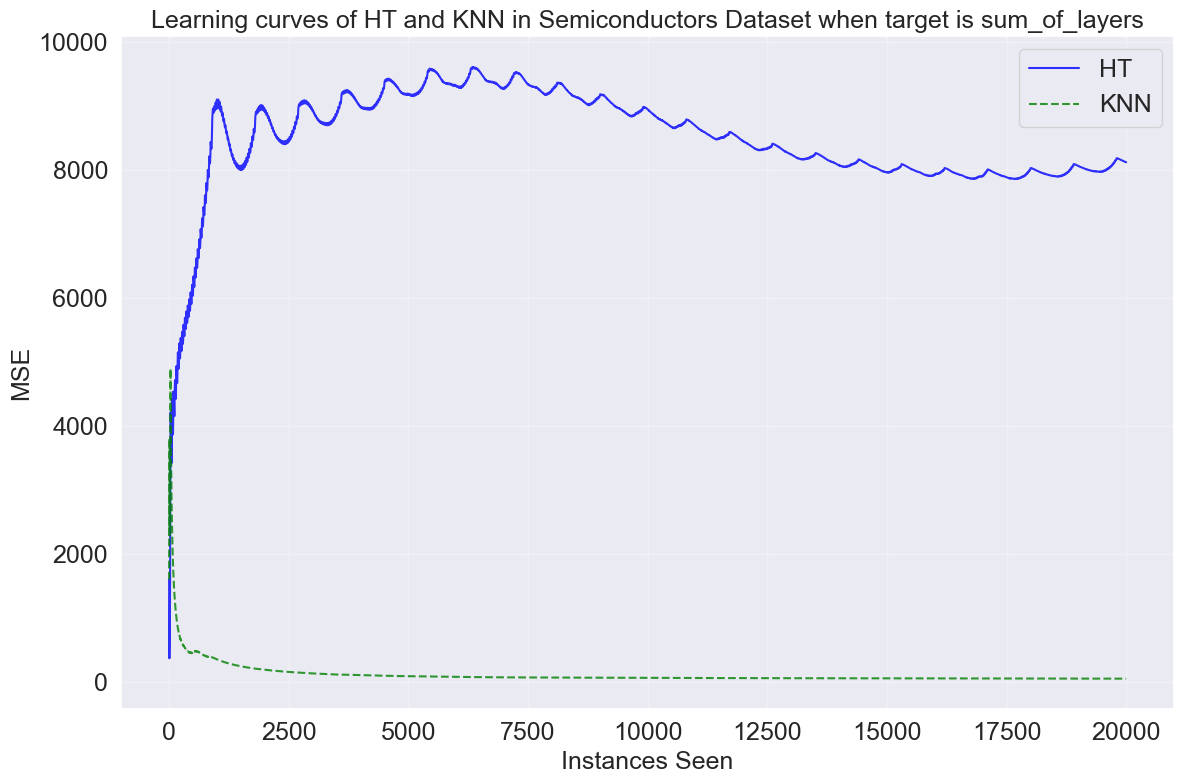

In [25]:
#Plot MSE
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

plt.figure(figsize=(12, 8))

# Plot without jitter
plt.plot(ht_mse_list, label='HT', color='blue', linewidth=1.5, linestyle='-', alpha=0.8)
plt.plot(knn_mse_list, label='KNN', color='green', linewidth=1.5, linestyle='--', alpha=0.8)

plt.title(f"Learning curves of HT and KNN in Semiconductors Dataset when target is sum_of_layers", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel("Instances Seen", fontsize=18)
plt.ylabel('MSE', fontsize=18)
plt.grid(alpha=0.3)
plt.legend(fontsize=18)
plt.tight_layout()

# Save the plot
save_path = '/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/figures/semiconductor/knn_ht/sum_of_layers/mse_curves.png'
plt.savefig(save_path)

plt.show()


# target : layer_4

In [32]:
from src.lazy import KNNRegressor
from src.trees import HoeffdingTreeRegressor
from sklearn.metrics import mean_squared_error

knn = KNNRegressor()
ht = HoeffdingTreeRegressor()
actual_labels = []
knn_predictions = []
ht_predictions = []
knn_mse_list = []
ht_mse_list = []

for i in range(len(X_4)):


    instance_features = X_4.iloc[i:i+1].values
    actual_value = y_4[i]
    actual_labels.append(actual_value)

    # Predict
    knn_pred = knn.predict(instance_features)[0]
    knn_predictions.append(knn_pred)

    knn_temp_mse = mean_squared_error(actual_labels, knn_predictions)
    knn_mse_list.append(knn_temp_mse)

    ht_pred = ht.predict(instance_features)[0]
    ht_predictions.append(ht_pred)

    ht_temp_mse = mean_squared_error(actual_labels, ht_predictions)
    ht_mse_list.append(ht_temp_mse)

    # Fit
    knn.partial_fit(X=instance_features, y=[actual_value])
    ht.partial_fit(X=instance_features, y=[actual_value])

knn_mse = mean_squared_error(actual_labels, knn_predictions)
ht_mse = mean_squared_error(actual_labels, ht_predictions)


/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operati

In [33]:
print(knn_mse)
print(ht_mse)

5580.7532
3334.8627081369755


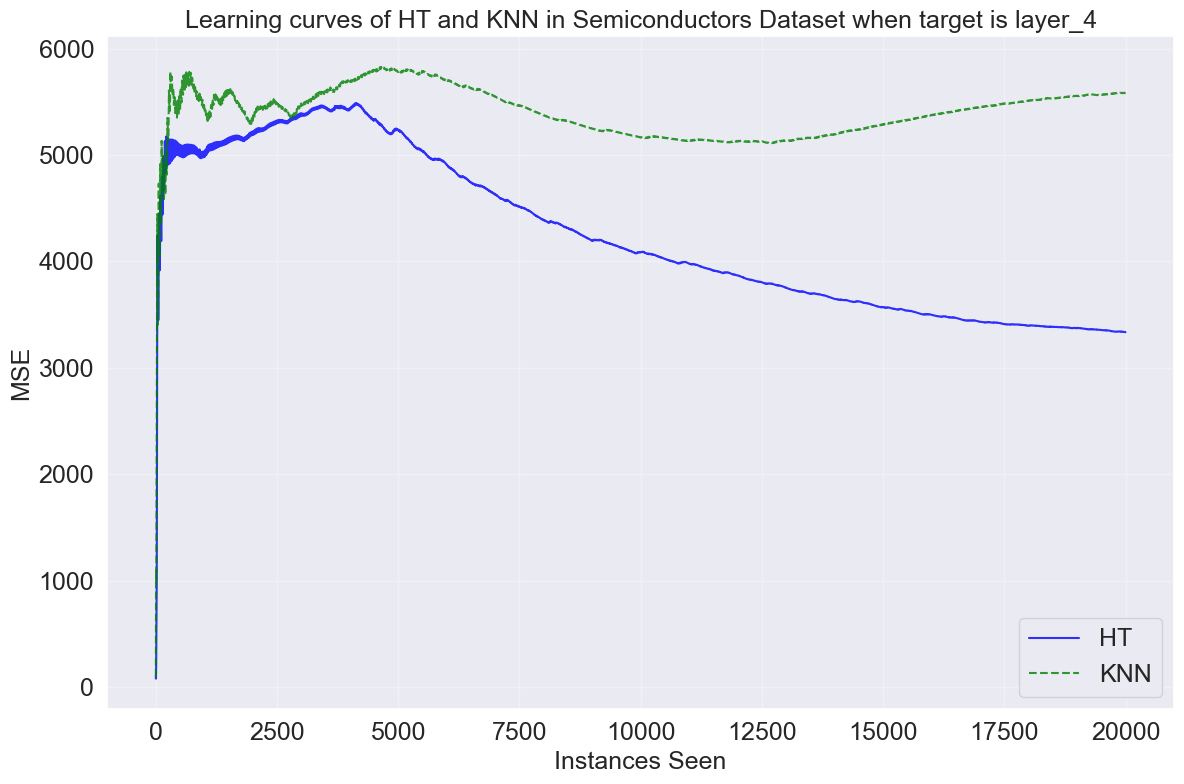

In [34]:
#Plot MSE
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

plt.figure(figsize=(12, 8))

# Plot without jitter
plt.plot(ht_mse_list, label='HT', color='blue', linewidth=1.5, linestyle='-', alpha=0.8)
plt.plot(knn_mse_list, label='KNN', color='green', linewidth=1.5, linestyle='--', alpha=0.8)

plt.title(f"Learning curves of HT and KNN in Semiconductors Dataset when target is layer_4", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel("Instances Seen", fontsize=18)
plt.ylabel('MSE', fontsize=18)
plt.grid(alpha=0.3)
plt.legend(fontsize=18)
plt.tight_layout()

# Save the plot
save_path = '/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/figures/semiconductor/knn_ht/layer_4/mse_curves.png'
plt.savefig(save_path)

plt.show()


# layer_1, layer_2, layer_3 as target

In [40]:
from src.lazy import KNNRegressor
from src.trees import HoeffdingTreeRegressor
from sklearn.metrics import mean_squared_error

layers_list = ['layer_1', 'layer_2', 'layer_3', 'layer_4']

for layer_name in layers_list:
    print(f"For : {layer_name}")
    X_layer = X_1
    y_layer = target_1
    knn = KNNRegressor()
    ht = HoeffdingTreeRegressor()
    actual_labels = []
    knn_predictions = []
    ht_predictions = []
    knn_mse_list = []
    ht_mse_list = []


    if layer_name == 'layer_2':
        X_layer  = X_2
        y_layer = target_2
    if layer_name == 'layer_3':
        X_layer  = X_3
        y_layer = target_3
    if layer_name == 'layer_4':
        X_layer  = X_4
        y_layer = y_4

    for i in range(len(X_layer)):

        instance_features = X_layer.iloc[i:i+1].values
        actual_value = y_layer[i]
        actual_labels.append(actual_value)

        # Predict
        knn_pred = knn.predict(instance_features)[0]
        knn_predictions.append(knn_pred)

        knn_temp_mse = mean_squared_error(actual_labels, knn_predictions)
        knn_mse_list.append(knn_temp_mse)

        ht_pred = ht.predict(instance_features)[0]
        ht_predictions.append(ht_pred)

        ht_temp_mse = mean_squared_error(actual_labels, ht_predictions)
        ht_mse_list.append(ht_temp_mse)

        # Fit
        knn.partial_fit(X=instance_features, y=[actual_value])
        ht.partial_fit(X=instance_features, y=[actual_value])

    knn_mse = mean_squared_error(actual_labels, knn_predictions)
    ht_mse = mean_squared_error(actual_labels, ht_predictions)

    print(knn_mse)
    print(ht_mse)


    #Plot MSE
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set_theme()

    plt.figure(figsize=(12, 8))

    # Plot without jitter
    plt.plot(ht_mse_list, label='HT', color='blue', linewidth=1.5, linestyle='-', alpha=0.8)
    plt.plot(knn_mse_list, label='KNN', color='green', linewidth=1.5, linestyle='--', alpha=0.8)

    plt.title(f"Learning curves of HT and KNN in Semiconductors Dataset when target is {layer_name}", fontsize=18)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.xlabel("Instances Seen", fontsize=18)
    plt.ylabel('MSE', fontsize=18)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=18)
    plt.tight_layout()

    # Save the plot
    save_path = '/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/figures/semiconductor/knn_ht/' +str(layer_name) +'/mse_curves.png'
    plt.savefig(save_path)

    plt.show()



For : layer_1


/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operati

KeyboardInterrupt: 

In [43]:
from src.lazy import KNNRegressor
from src.trees import HoeffdingTreeRegressor
from sklearn.metrics import mean_squared_error

layers_list = ['layer_1', 'layer_2', 'layer_3', 'layer_4']

for layer_name in layers_list:
    print(f"For : {layer_name}")
    X_layer = X_1
    y_layer = target_1
    knn = KNNRegressor()
    ht = HoeffdingTreeRegressor()
    actual_labels = []
    knn_predictions = []
    ht_predictions = []
    knn_mse_list = []
    ht_mse_list = []

    if layer_name == 'layer_1':
        max_decimal_digits_y_true = max(count_decimals(x) for x in target_1)
        print("Maximum number of decimal digits from layer_1 :", max_decimal_digits_y_true)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/with_rest_targets_as_features/layer_1/y_true.txt", target_1, fmt="%." +str(max_decimal_digits_y_true)+"f")

    if layer_name == 'layer_2':
        X_layer  = X_2
        y_layer = target_2

        max_decimal_digits_y_true = max(count_decimals(x) for x in target_2)
        print("Maximum number of decimal digits from layer_2 :", max_decimal_digits_y_true)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/with_rest_targets_as_features/layer_2/y_true.txt", target_2, fmt="%." +str(max_decimal_digits_y_true)+"f")

    if layer_name == 'layer_3':
        X_layer  = X_3
        y_layer = target_3

        max_decimal_digits_y_true = max(count_decimals(x) for x in target_1)
        print("Maximum number of decimal digits from layer_3 :", max_decimal_digits_y_true)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/with_rest_targets_as_features/layer_3/y_true.txt", target_3, fmt="%." +str(max_decimal_digits_y_true)+"f")

    if layer_name == 'layer_4':
        X_layer  = X_4
        y_layer = y_4

        max_decimal_digits_y_true = max(count_decimals(x) for x in y_4)
        print("Maximum number of decimal digits from layer_4 :", max_decimal_digits_y_true)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/with_rest_targets_as_features/layer_4/y_true.txt", y_4, fmt="%." +str(max_decimal_digits_y_true)+"f")

    for i in range(len(X_layer)):

        instance_features = X_layer.iloc[i:i+1].values
        actual_value = y_layer[i]
        actual_labels.append(actual_value)

        # Predict
        knn_pred = knn.predict(instance_features)[0]
        knn_predictions.append(knn_pred)

        ht_pred = ht.predict(instance_features)[0]
        ht_predictions.append(ht_pred)

        # Fit
        knn.partial_fit(X=instance_features, y=[actual_value])
        ht.partial_fit(X=instance_features, y=[actual_value])

    knn_mse = mean_squared_error(actual_labels, knn_predictions)
    ht_mse = mean_squared_error(actual_labels, ht_predictions)

    print(knn_mse)
    print(ht_mse)

    if layer_name == 'layer_1':
        max_decimal_digits_knn = max(count_decimals(x) for x in knn_predictions)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/with_rest_targets_as_features/layer_1/knn.txt", knn_predictions, fmt="%." +str(max_decimal_digits_knn)+"f")

        max_decimal_digits_ht = max(count_decimals(x) for x in ht_predictions)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/with_rest_targets_as_features/layer_1/ht.txt", ht_predictions, fmt="%." +str(max_decimal_digits_ht)+"f")

    if layer_name == 'layer_2':
        max_decimal_digits_knn = max(count_decimals(x) for x in knn_predictions)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/with_rest_targets_as_features/layer_2/knn.txt", knn_predictions, fmt="%." +str(max_decimal_digits_knn)+"f")

        max_decimal_digits_ht = max(count_decimals(x) for x in ht_predictions)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/with_rest_targets_as_features/layer_2/ht.txt", ht_predictions, fmt="%." +str(max_decimal_digits_ht)+"f")

    if layer_name == 'layer_3':

        max_decimal_digits_knn = max(count_decimals(x) for x in knn_predictions)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/with_rest_targets_as_features/layer_3/knn.txt", knn_predictions, fmt="%." +str(max_decimal_digits_knn)+"f")

        max_decimal_digits_ht = max(count_decimals(x) for x in ht_predictions)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/with_rest_targets_as_features/layer_3/ht.txt", ht_predictions, fmt="%." +str(max_decimal_digits_ht)+"f")

    if layer_name == 'layer_4':

        max_decimal_digits_knn = max(count_decimals(x) for x in knn_predictions)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/with_rest_targets_as_features/layer_4/knn.txt", knn_predictions, fmt="%." +str(max_decimal_digits_knn)+"f")

        max_decimal_digits_ht = max(count_decimals(x) for x in ht_predictions)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/with_rest_targets_as_features/layer_4/ht.txt", ht_predictions, fmt="%." +str(max_decimal_digits_ht)+"f")

For : layer_1
Maximum number of decimal digits from layer_1 : 0


/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operati

0.025
0.005
For : layer_2
Maximum number of decimal digits from layer_2 : 0


/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operati

36.6762
1820.3445635930725
For : layer_3
Maximum number of decimal digits from layer_3 : 0


/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operati

5398.5608
2937.5138955878465
For : layer_4
Maximum number of decimal digits from layer_4 : 0


/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operati

5580.7532
3334.867428491475


# Do the same but without rest tagerts as features

In [42]:
from src.lazy import KNNRegressor
from src.trees import HoeffdingTreeRegressor
from sklearn.metrics import mean_squared_error

layers_list = ['layer_1', 'layer_2', 'layer_3', 'layer_4']

for layer_name in layers_list:
    print(f"For : {layer_name}")
    X_layer = X
    y_layer = target_1
    knn = KNNRegressor()
    ht = HoeffdingTreeRegressor()
    actual_labels = []
    knn_predictions = []
    ht_predictions = []
    knn_mse_list = []
    ht_mse_list = []

    if layer_name == 'layer_1':
        max_decimal_digits_y_true = max(count_decimals(x) for x in target_1)
        print("Maximum number of decimal digits from layer_1 :", max_decimal_digits_y_true)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/without_rest_targets_as_features/layer_1/y_true.txt", target_1, fmt="%." +str(max_decimal_digits_y_true)+"f")

    if layer_name == 'layer_2':
        y_layer = target_2

        max_decimal_digits_y_true = max(count_decimals(x) for x in target_2)
        print("Maximum number of decimal digits from layer_2 :", max_decimal_digits_y_true)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/without_rest_targets_as_features/layer_2/y_true.txt", target_2, fmt="%." +str(max_decimal_digits_y_true)+"f")

    if layer_name == 'layer_3':
        y_layer = target_3

        max_decimal_digits_y_true = max(count_decimals(x) for x in target_1)
        print("Maximum number of decimal digits from layer_3 :", max_decimal_digits_y_true)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/without_rest_targets_as_features/layer_3/y_true.txt", target_3, fmt="%." +str(max_decimal_digits_y_true)+"f")

    if layer_name == 'layer_4':
        y_layer = y_4

        max_decimal_digits_y_true = max(count_decimals(x) for x in y_4)
        print("Maximum number of decimal digits from layer_4 :", max_decimal_digits_y_true)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/without_rest_targets_as_features/layer_4/y_true.txt", y_4, fmt="%." +str(max_decimal_digits_y_true)+"f")

    for i in range(len(X_layer)):

        instance_features = X_layer.iloc[i:i+1].values
        actual_value = y_layer[i]
        actual_labels.append(actual_value)

        # Predict
        knn_pred = knn.predict(instance_features)[0]
        knn_predictions.append(knn_pred)

        ht_pred = ht.predict(instance_features)[0]
        ht_predictions.append(ht_pred)

        # Fit
        knn.partial_fit(X=instance_features, y=[actual_value])
        ht.partial_fit(X=instance_features, y=[actual_value])

    knn_mse = mean_squared_error(actual_labels, knn_predictions)
    ht_mse = mean_squared_error(actual_labels, ht_predictions)

    print(knn_mse)
    print(ht_mse)

    if layer_name == 'layer_1':

        max_decimal_digits_knn = max(count_decimals(x) for x in knn_predictions)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/without_rest_targets_as_features/layer_1/knn.txt", knn_predictions, fmt="%." +str(max_decimal_digits_knn)+"f")

        max_decimal_digits_ht = max(count_decimals(x) for x in ht_predictions)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/without_rest_targets_as_features/layer_1/ht.txt", ht_predictions, fmt="%." +str(max_decimal_digits_ht)+"f")

    if layer_name == 'layer_2':
        max_decimal_digits_knn = max(count_decimals(x) for x in knn_predictions)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/without_rest_targets_as_features/layer_2/knn.txt", knn_predictions, fmt="%." +str(max_decimal_digits_knn)+"f")

        max_decimal_digits_ht = max(count_decimals(x) for x in ht_predictions)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/without_rest_targets_as_features/layer_2/ht.txt", ht_predictions, fmt="%." +str(max_decimal_digits_ht)+"f")

    if layer_name == 'layer_3':

        max_decimal_digits_knn = max(count_decimals(x) for x in knn_predictions)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/without_rest_targets_as_features/layer_3/knn.txt", knn_predictions, fmt="%." +str(max_decimal_digits_knn)+"f")

        max_decimal_digits_ht = max(count_decimals(x) for x in ht_predictions)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/without_rest_targets_as_features/layer_3/ht.txt", ht_predictions, fmt="%." +str(max_decimal_digits_ht)+"f")

    if layer_name == 'layer_4':

        max_decimal_digits_knn = max(count_decimals(x) for x in knn_predictions)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/without_rest_targets_as_features/layer_4/knn.txt", knn_predictions, fmt="%." +str(max_decimal_digits_knn)+"f")

        max_decimal_digits_ht = max(count_decimals(x) for x in ht_predictions)

        np.savetxt("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/predictions/film_thickness/without_rest_targets_as_features/layer_4/ht.txt", ht_predictions, fmt="%." +str(max_decimal_digits_ht)+"f")

For : layer_1
Maximum number of decimal digits from layer_1 : 0


/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operati

0.025
0.005
For : layer_2
Maximum number of decimal digits from layer_2 : 0


/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operati

52.3162
1750.977944542512
For : layer_3
Maximum number of decimal digits from layer_3 : 0


/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operati

126.392
2907.155765354931
For : layer_4
Maximum number of decimal digits from layer_4 : 0


/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = self._predict(X)
/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/lazy/knn_regressor.py:154: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operati

226.874
3340.028745773847
